In [94]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [95]:
# =========================================================
# 1. Load data
# =========================================================
traces = np.load("ML_trace.npy", mmap_mode="r")   # (N, L), e.g. (5000, 3224)
plain  = np.load("ML_plain.npy", mmap_mode="r")   # (N, 16)
key    = np.load("ML_key.npy", mmap_mode="r")     # (16,) or (N, 16)

print("traces shape:", traces.shape)
print("plain shape :", plain.shape)
print("key shape   :", key.shape)

traces shape: (5000, 3224)
plain shape : (5000, 16)
key shape   : (5000, 16)


In [96]:
# =========================================================
# 2. AES SBOX / HW(SBOX)
# =========================================================
SBOX = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16
], dtype=np.uint8)

HW_SBOX = np.array([
     4, 5, 6, 6, 5, 5, 6, 4, 2, 1, 5, 4, 7, 6, 5, 5,
     4, 2, 4, 6, 6, 4, 4, 4, 5, 4, 3, 6, 4, 3, 4, 2,
     6, 7, 4, 3, 4, 6, 7, 4, 3, 4, 5, 5, 4, 4, 3, 3,
     1, 5, 3, 4, 2, 4, 2, 4, 3, 2, 1, 4, 6, 4, 4, 5,
     2, 3, 3, 3, 4, 5, 4, 2, 3, 5, 5, 5, 3, 5, 5, 2,
     4, 4, 0, 6, 1, 6, 4, 5, 4, 5, 6, 4, 3, 3, 3, 6,
     3, 7, 4, 7, 3, 4, 4, 3, 3, 6, 1, 7, 2, 4, 6, 3,
     3, 4, 1, 5, 3, 5, 3, 6, 5, 5, 5, 2, 1, 8, 6, 4,
     5, 2, 3, 5, 6, 5, 2, 4, 3, 5, 6, 5, 3, 5, 3, 5,
     2, 2, 5, 5, 2, 3, 2, 2, 3, 6, 4, 2, 6, 5, 3, 6,
     3, 3, 4, 2, 3, 2, 2, 4, 3, 5, 4, 3, 3, 4, 4, 5,
     6, 3, 5, 5, 4, 5, 4, 4, 4, 4, 5, 5, 4, 5, 5, 1,
     5, 4, 3, 4, 3, 4, 4, 4, 4, 6, 4, 5, 4, 6, 4, 3,
     3, 5, 5, 4, 2, 2, 6, 3, 3, 4, 5, 5, 3, 3, 4, 5,
     4, 5, 3, 2, 4, 5, 4, 3, 5, 4, 4, 5, 5, 4, 2, 7,
     3, 3, 3, 3, 7, 5, 2, 3, 2, 4, 4, 4, 3, 3, 6, 3
], dtype=np.uint8)

In [97]:
# =========================================================
# 3. 파형 전처리
# =========================================================
traces = np.asarray(traces, dtype=np.float32)

mu = traces.mean(axis=0)
std = traces.std(axis=0)
eps = 1e-8

traces_norm = (traces - mu) / (std + eps)
print("traces_norm shape:", traces_norm.shape)

traces_norm shape: (5000, 3224)


In [98]:
# =========================================================
# 4. 중간값 및 라벨 생성 함수
# =========================================================

def interm_and_label(target_byte, guesskey):
    pt_byte = plain[:, target_byte].astype(np.uint8)
    xor = np.bitwise_xor(guesskey, pt_byte)
    labels = HW_SBOX[xor].astype(np.int64)   # 0~8
    return labels

In [99]:
# =========================================================
# 5. Dataset
#    Pytorch가 trace와 label을 배치 단위로 꺼내서 학습할 수 있도록 만드는 데이터 포장 클래스
#    CNN 학습할 때는 데이터를 배치 단위로 나눠서 반복
# =========================================================

class TraceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)   # (N, 1, L)
        self.y = torch.tensor(y, dtype=torch.long)      # (N,)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [100]:
# =========================================================
# 6. Model: CNN_exp
# =========================================================
class CNNExp(nn.Module):
    def __init__(self, input_len, num_classes=9):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=4,
            kernel_size=32,
            stride=1
        )
        self.conv2 = nn.Conv1d(
            in_channels=4,
            out_channels=4,
            kernel_size=16,
            stride=1
        )
        self.pool = nn.MaxPool1d(kernel_size=2)

        with torch.no_grad():
            z = torch.zeros(1, 1, input_len)
            z = self.pool(F.relu(self.conv1(z)))
            z = self.pool(F.relu(self.conv2(z)))
            flat_dim = z.numel()

        self.fc1 = nn.Linear(flat_dim, 32)
        self.fc2 = nn.Linear(32, num_classes)  # HW 0~8 -> 9 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)   # logits (9개의 점수가 나옴 - Softmax 내장)
        return x

In [ ]:
# =========================================================
# 7. Full Key Recovery: 바이트 0~15 전체 반복 (Acc & Loss 기록)
# =========================================================
epochs = 15
batch_size = 512
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N, L = traces_norm.shape
traces_cnn = traces_norm.reshape((N, 1, L))

# 전체 바이트의 학습 기록을 저장할 리스트 (Acc, Loss 각각 생성)
all_bytes_acc = np.zeros((16, 256, epochs)) 
all_bytes_loss = np.zeros((16, 256, epochs))
recovered_full_key_acc = []
recovered_full_key_loss = []

for target_byte in range(16):
    print(f"\n[>>>] Attacking Byte {target_byte}...")
    
    for guess in range(256):
        labels = interm_and_label(target_byte, guess)  # 중간값 계산
        dataset = TraceDataset(traces_cnn, labels)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        model = CNNExp(input_len=L, num_classes=9).to(device) # 모델 선언
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        
        for epoch in range(epochs):
            model.train() 
            running_loss = 0.0
            correct = 0
            total = 0
            for batch_x, batch_y in dataloader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device) # 데이터를 batch_size만큼씩 잘라서 가져옴
                optimizer.zero_grad() # 이전 기울기 초기화
                outputs = model(batch_x) # 모델이 파형을 보고 9개의 점수 출력
                loss = criterion(outputs, batch_y) # 모델이 낸 답과 중간값 라벨을 비교해서 loss 점수를 냄
                loss.backward() # 역전파
                optimizer.step() # 가중치 수정
                
                running_loss += loss.item() * batch_x.size(0) # 틀린 점수들을 더해서 누적
                _, predicted = torch.max(outputs.data, 1) # 9개 확률 중 가장 높은 확률을 가진 인덱스를 모델 최종 답으로 선택
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item() # 그 답이 실제 라벨과 똑같은 개수를 카운트
            
            # 에포크별 기록
            all_bytes_acc[target_byte, guess, epoch] = correct / total # 이번 키가 이번 epoch에서 낸 최종 정확도 저장
            all_bytes_loss[target_byte, guess, epoch] = running_loss / total # 평균 손실 값 저장
            
        if guess % 64 == 0:
            print(f"  Byte {target_byte} | Guess {guess:03d} 완료")

    # 지표별 최적 키 추출
    best_guess_acc = np.argmax(all_bytes_acc[target_byte, :, -1])
    best_guess_loss = np.argmin(all_bytes_loss[target_byte, :, -1]) # Loss는 최소값
    
    recovered_full_key_acc.append(best_guess_acc)
    recovered_full_key_loss.append(best_guess_loss)


[>>>] Attacking Byte 0...
  Byte 0 | Guess 000 완료
  Byte 0 | Guess 064 완료
  Byte 0 | Guess 128 완료
  Byte 0 | Guess 192 완료

[>>>] Attacking Byte 1...
  Byte 1 | Guess 000 완료
  Byte 1 | Guess 064 완료
  Byte 1 | Guess 128 완료
  Byte 1 | Guess 192 완료

[>>>] Attacking Byte 2...
  Byte 2 | Guess 000 완료
  Byte 2 | Guess 064 완료
  Byte 2 | Guess 128 완료
  Byte 2 | Guess 192 완료

[>>>] Attacking Byte 3...
  Byte 3 | Guess 000 완료
  Byte 3 | Guess 064 완료
  Byte 3 | Guess 128 완료
  Byte 3 | Guess 192 완료

[>>>] Attacking Byte 4...
  Byte 4 | Guess 000 완료
  Byte 4 | Guess 064 완료
  Byte 4 | Guess 128 완료
  Byte 4 | Guess 192 완료

[>>>] Attacking Byte 5...
  Byte 5 | Guess 000 완료
  Byte 5 | Guess 064 완료
  Byte 5 | Guess 128 완료
  Byte 5 | Guess 192 완료

[>>>] Attacking Byte 6...
  Byte 6 | Guess 000 완료
  Byte 6 | Guess 064 완료
  Byte 6 | Guess 128 완료
  Byte 6 | Guess 192 완료

[>>>] Attacking Byte 7...
  Byte 7 | Guess 000 완료
  Byte 7 | Guess 064 완료
  Byte 7 | Guess 128 완료
  Byte 7 | Guess 192 완료

[>>>] Attacking

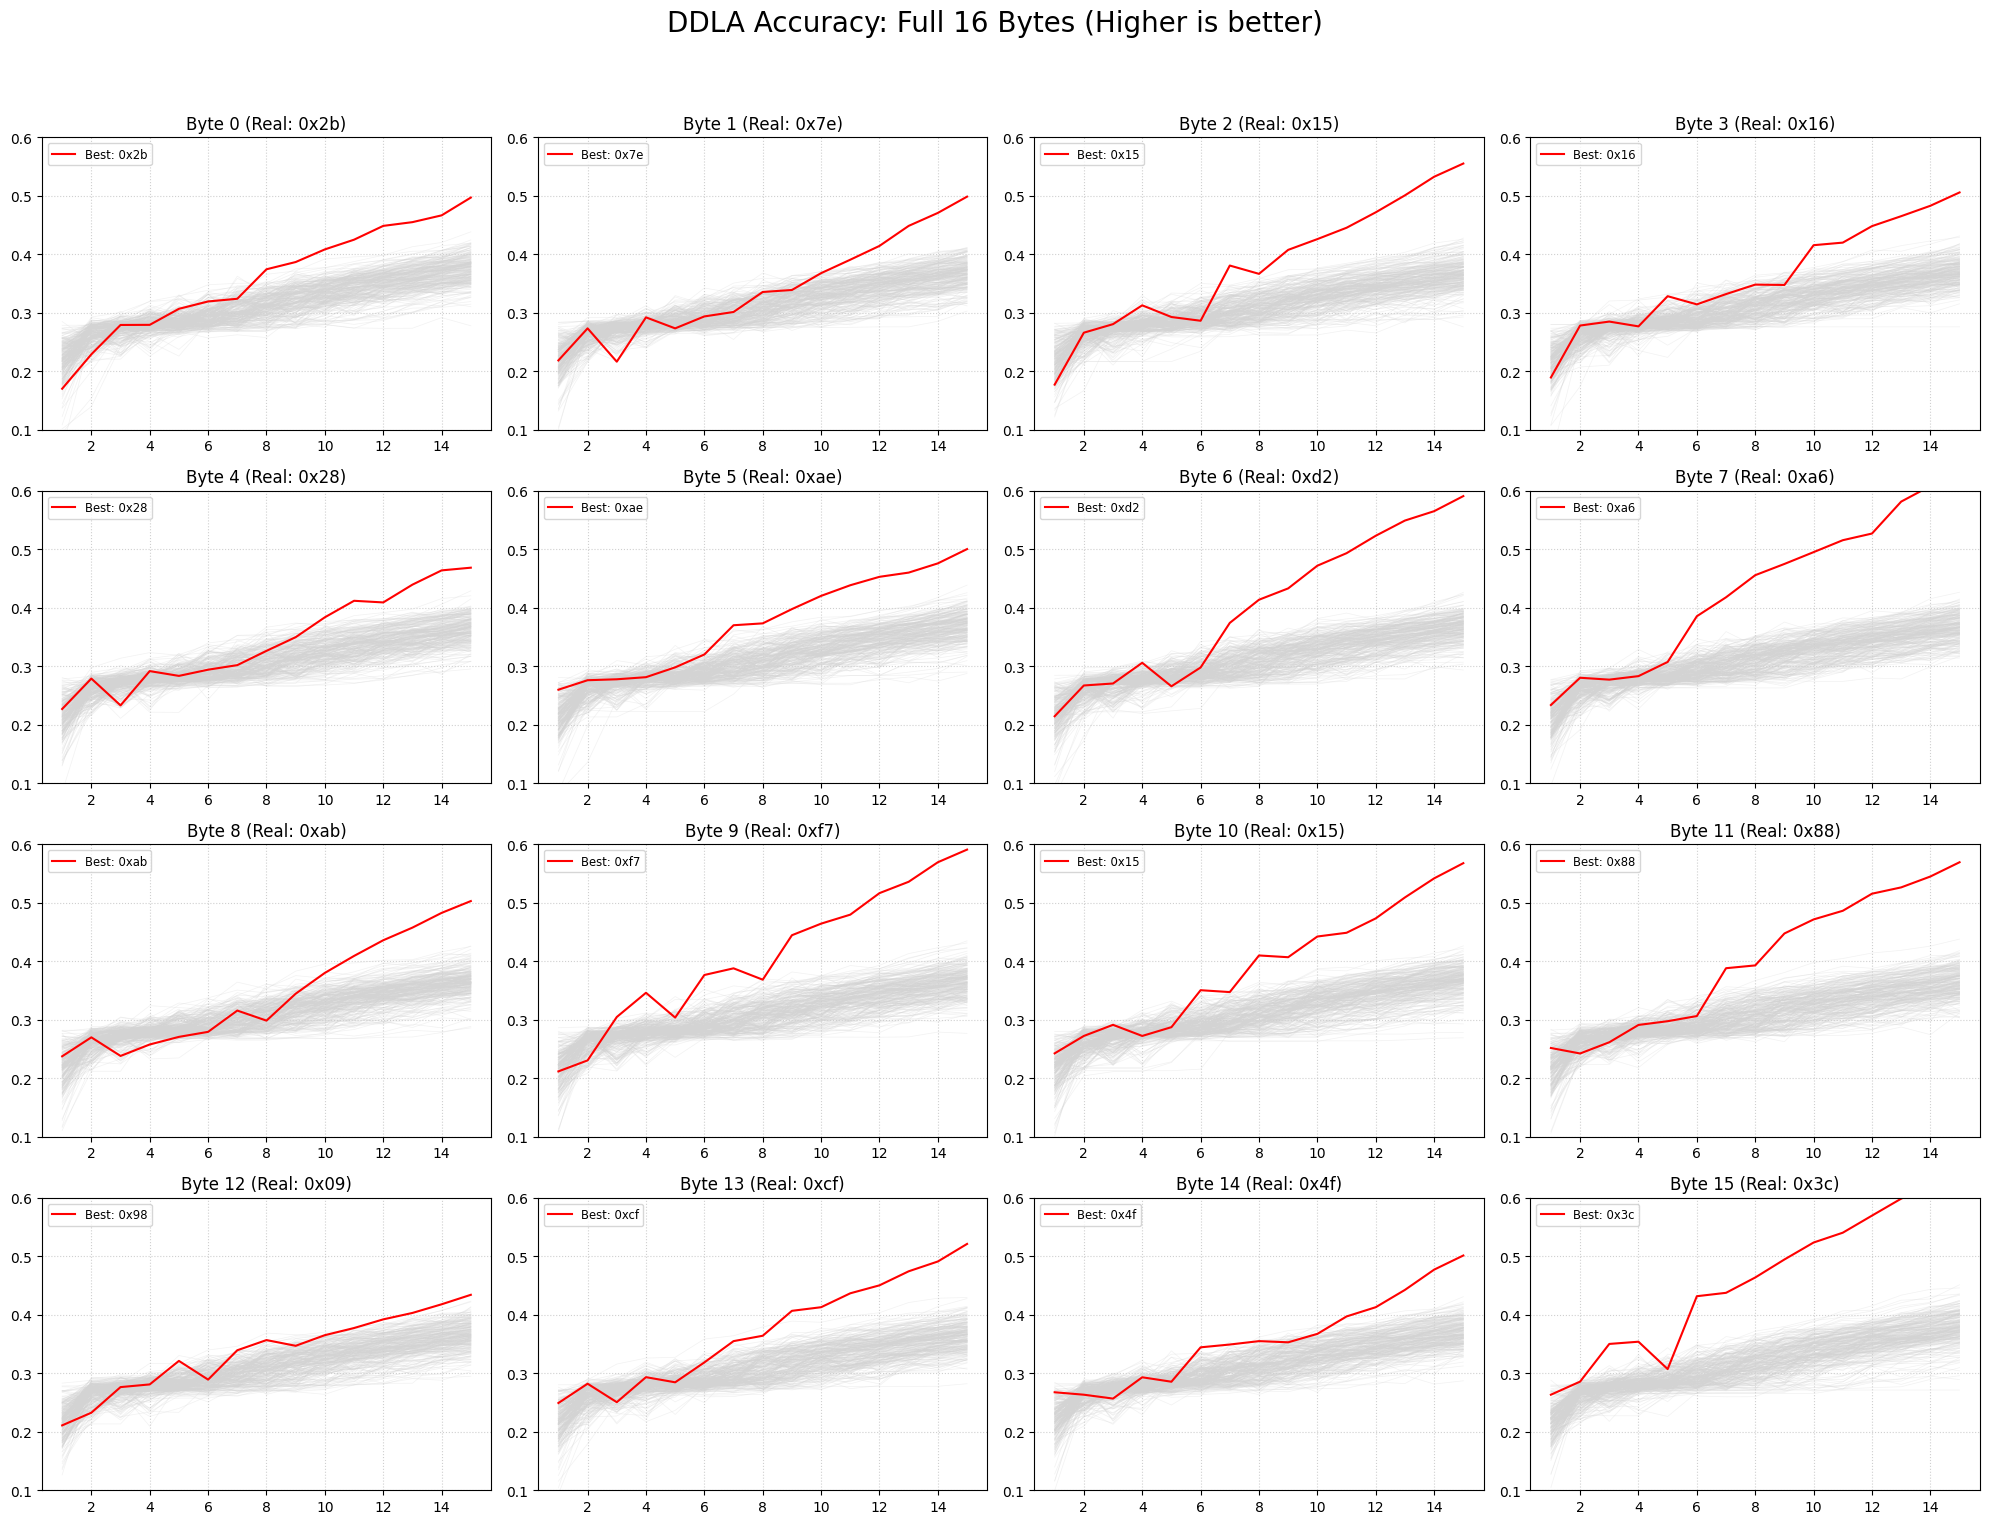

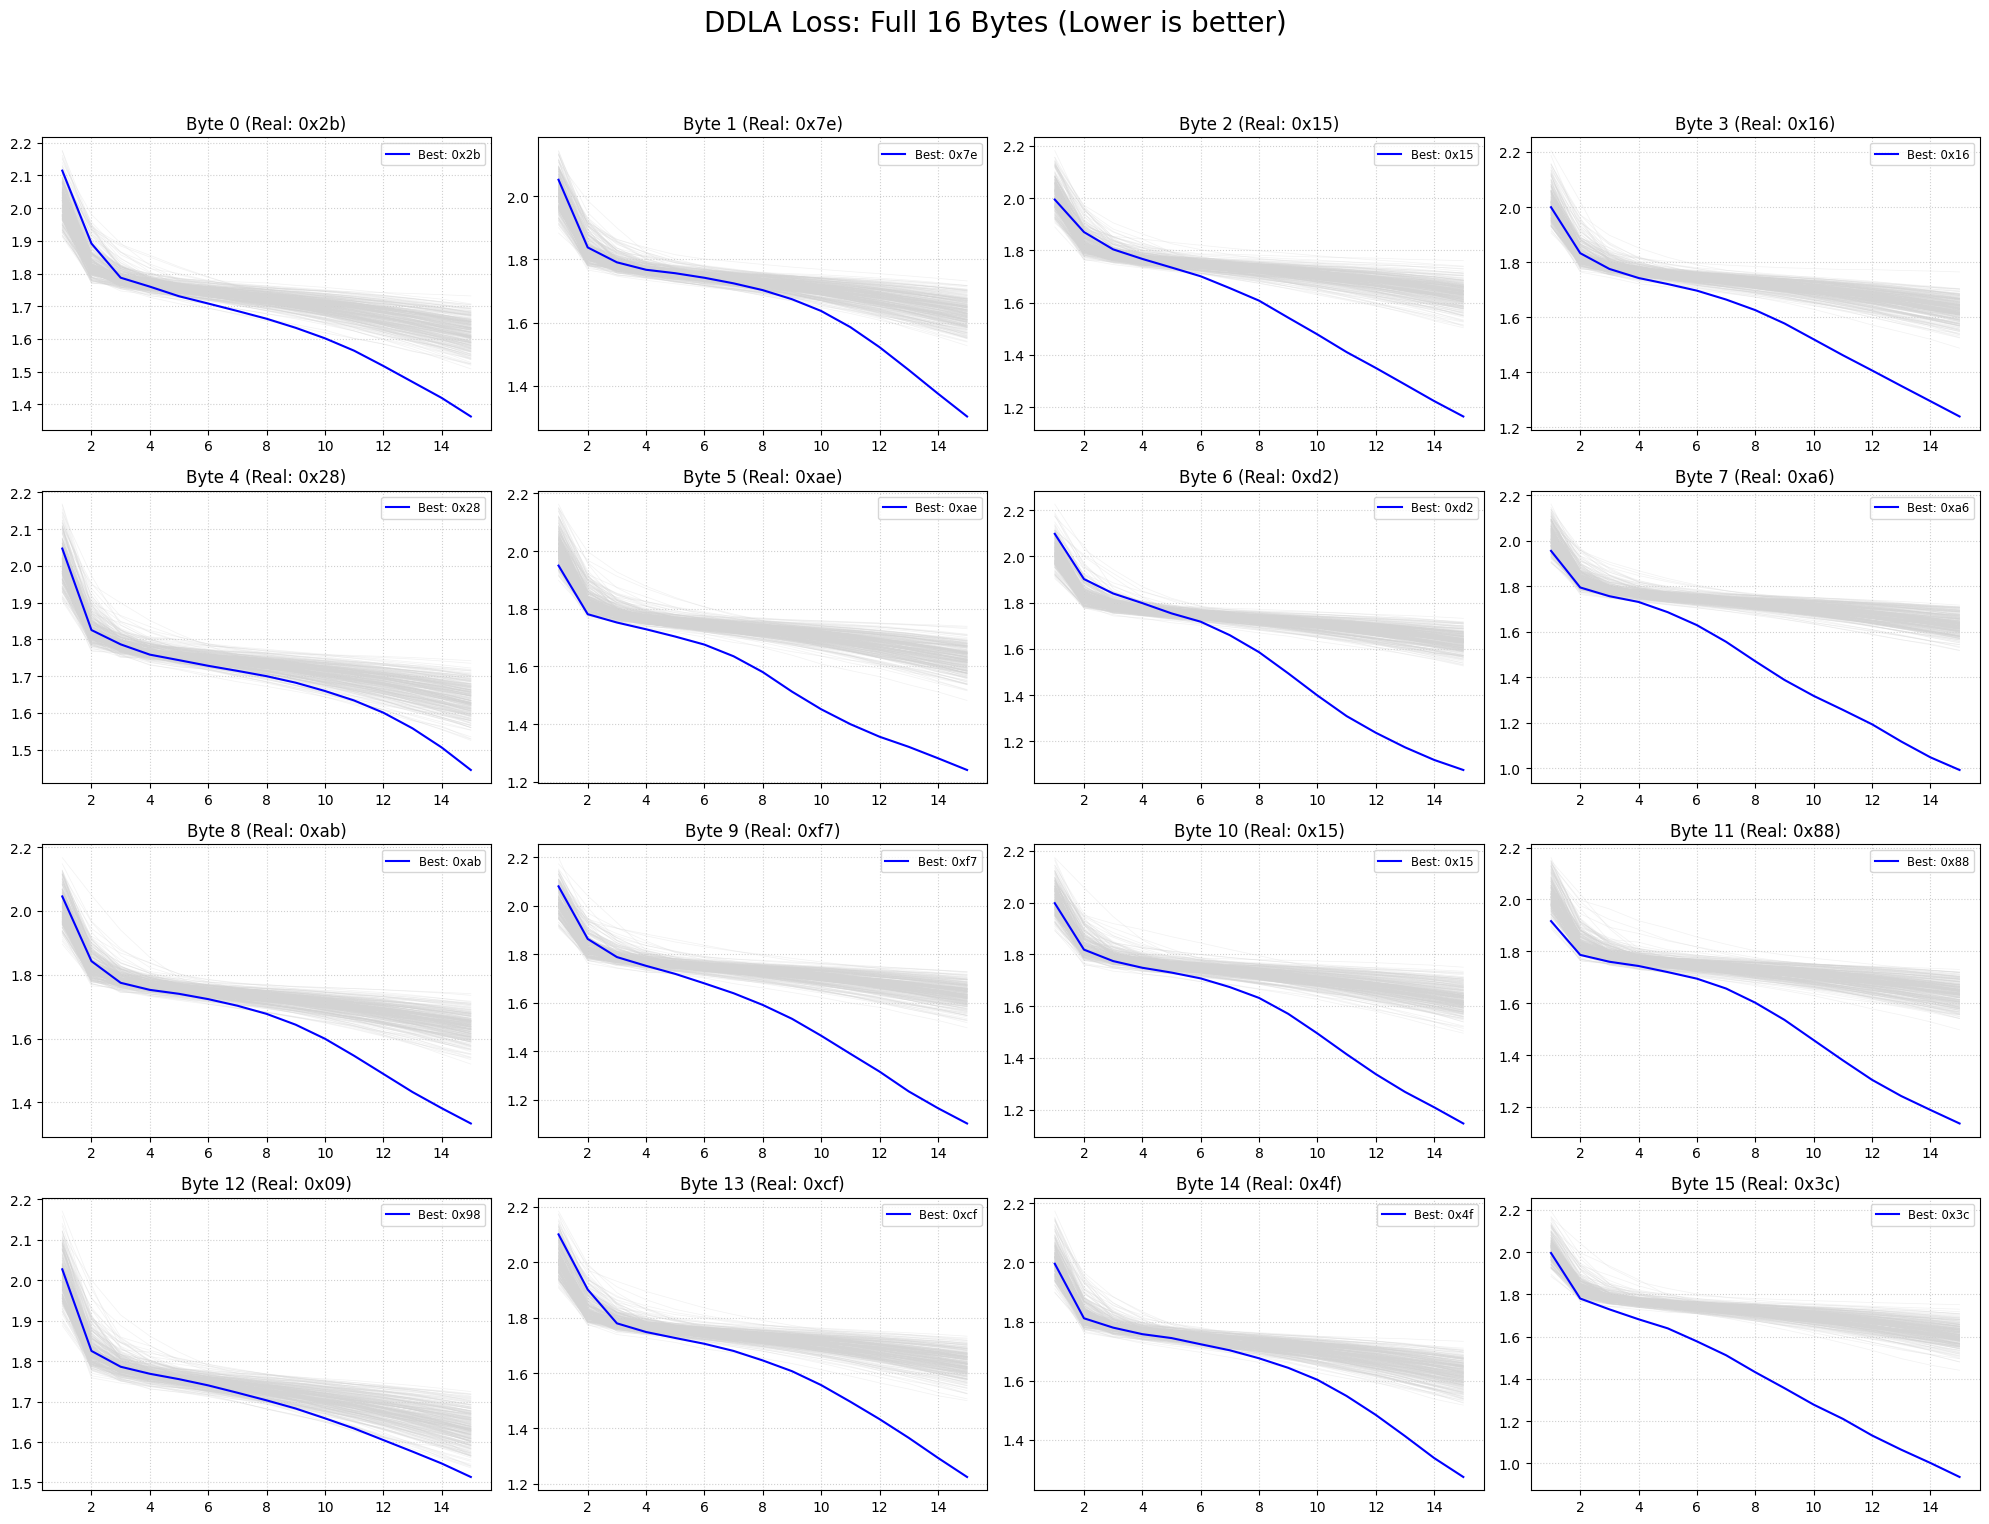


Final Key (by Acc):  2b 7e 15 16 28 ae d2 a6 ab f7 15 88 98 cf 4f 3c
Final Key (by Loss): 2b 7e 15 16 28 ae d2 a6 ab f7 15 88 98 cf 4f 3c


In [102]:
# =========================================================
# 8. 4x4 Grid Visualization: Training ACCURACY
# =========================================================
def plot_4x4_grid(history_data, metric_name, is_loss=False):
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))
    title_prefix = "Lower is better" if is_loss else "Higher is better"
    fig.suptitle(f'DDLA {metric_name}: Full 16 Bytes ({title_prefix})', fontsize=20)

    for i in range(16):
        ax = axes[i // 4, i % 4]
        byte_data = history_data[i]
        
        # 정답 후보 인덱스 찾기
        best_k = np.argmin(byte_data[:, -1]) if is_loss else np.argmax(byte_data[:, -1])
        real_k = key[0, i] if key.ndim == 2 else key[i]
        
        for k in range(256):
            if k != best_k:
                ax.plot(range(1, epochs + 1), byte_data[k, :], color='lightgray', alpha=0.3, linewidth=0.5)
        
        # 최적 키는 색상을 다르게 (Acc: Red, Loss: Blue)
        line_color = 'blue' if is_loss else 'red'
        ax.plot(range(1, epochs + 1), byte_data[best_k, :], color=line_color, linewidth=1.5, 
                label=f'Best: 0x{best_k:02x}')
        
        ax.set_title(f'Byte {i} (Real: 0x{real_k:02x})')
        if not is_loss: ax.set_ylim([0.1, 0.6]) # Accuracy용 범위
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper left' if not is_loss else 'upper right', fontsize='small')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"ddla_4x4_{metric_name.lower()}.png")
    plt.show()

# 정확도 그래프 출력
plot_4x4_grid(all_bytes_acc, "Accuracy", is_loss=False)

# 손실 그래프 출력
plot_4x4_grid(all_bytes_loss, "Loss", is_loss=True)

print("\nFinal Key (by Acc): ", " ".join([f"{k:02x}" for k in recovered_full_key_acc]))
print("Final Key (by Loss):", " ".join([f"{k:02x}" for k in recovered_full_key_loss]))